# IT549: Deep Learning – Lab 3
## Image-Based AQI Classification using CNN and Pretrained Models

#### Name: Jimesh Rana
#### Student ID: 202511061
#### Dataset: [Google Drive Link](https://drive.google.com/drive/folders/1usBxgNB67GfhCQ2f7xRkDlF6fgIZZrP?usp=sharing)

## Setup & Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## Task 1 – Data Preparation

In [2]:
# ─── CONFIGURE PATHS ───────────────────────────────────────────────────────────
DATA_CSV      = "C:/Users/jimes/Desktop/collge/Sem-2 subject/IT549-Deep Learning-Arpit Rana/Lab/data.csv"          # path to data.csv
IMAGES_DIR    = "C:/Users/jimes/Desktop/collge/Sem-2 subject/IT549-Deep Learning-Arpit Rana/Lab/sampled_images-20260313T103941Z-3-001/sampled_images"    # root folder containing images
IMG_SIZE      = 224
BATCH_SIZE    = 64
EPOCHS        = 5
LR            = 1e-3
# ───────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(DATA_CSV)
print('Columns:', df.columns.tolist())
print('Shape  :', df.shape)
df.head()

Columns: ['Filename', 'AQI', 'PM2.5', 'PM10', 'O3', 'CO', 'SO2', 'NO2', 'AQI_Class']
Shape  : (6000, 9)


,Filename,AQI,PM2.5,PM10,O3,CO,SO2,NO2,AQI_Class
0,BENGR_Good_2023-03-25-08.30-1-43.jpg,32,13.0,32.0,31.0,219.0,10.0,20.0,a_Good
1,BENGR_Good_2023-02-28-08.30-1-11.jpg,37,19.0,37.0,18.0,272.0,11.0,21.0,a_Good
2,BENGR_Good_2023-02-28-08.30-1-551.jpg,37,19.0,37.0,18.0,272.0,11.0,21.0,a_Good
3,TN_Good_2023-02-27-16.30-1-196.jpg,43,22.0,40.0,36.0,268.0,16.0,7.0,a_Good
4,BENGR_Good_2023-02-27-08.30-1-276.jpg,47,24.0,46.0,19.0,216.0,8.0,14.0,a_Good


In [3]:
# Keep only required columns
df = df[['Filename', 'AQI_Class']].dropna()

# Encode labels
classes = sorted(df['AQI_Class'].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
df['label'] = df['AQI_Class'].map(class_to_idx)
NUM_CLASSES = len(classes)

print(f'Classes ({NUM_CLASSES}):', classes)
print('Class distribution:')
print(df['AQI_Class'].value_counts())

Classes (6): ['a_Good', 'b_Moderate', 'c_Unhealthy_for_Sensitive_Groups', 'd_Unhealthy', 'e_Very_Unhealthy', 'f_Severe']
Class distribution:
AQI_Class
a_Good                              1000
b_Moderate                          1000
c_Unhealthy_for_Sensitive_Groups    1000
d_Unhealthy                         1000
e_Very_Unhealthy                    1000
f_Severe                            1000
Name: count, dtype: int64


In [4]:
# Train / Val / Test split  (70 / 15 / 15)
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 4200 | Val: 900 | Test: 900


In [5]:
# ─── Dataset class ─────────────────────────────────────────────────────────────
class AQIDataset(Dataset):
    def __init__(self, dataframe, images_dir, transform=None):
        self.df         = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        img_path  = os.path.join(self.images_dir, row['Filename'])
        image     = Image.open(img_path).convert('RGB')
        label     = int(row['label'])
        if self.transform:
            image = self.transform(image)
        return image, label

# ─── Transforms ────────────────────────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ─── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(AQIDataset(train_df, IMAGES_DIR, train_transforms),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(AQIDataset(val_df,   IMAGES_DIR, eval_transforms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(AQIDataset(test_df,  IMAGES_DIR, eval_transforms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('DataLoaders ready.')

DataLoaders ready.


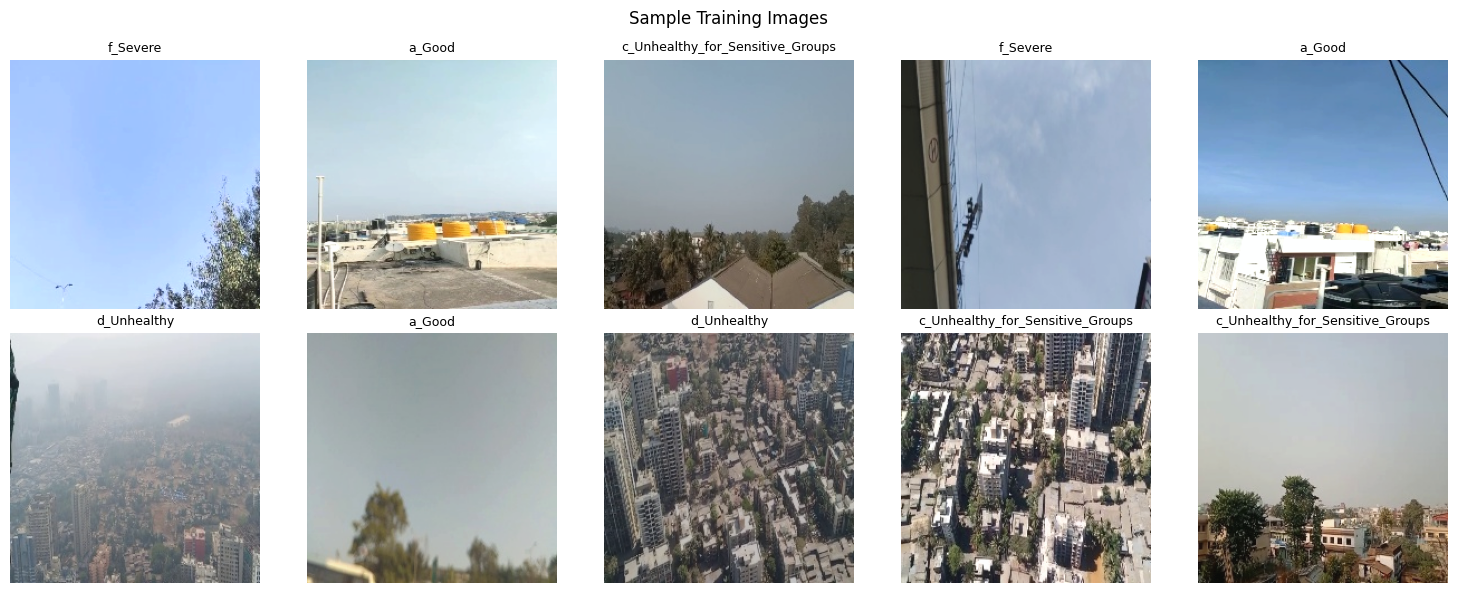

In [6]:
# Visualise a batch of training samples
imgs, lbls = next(iter(train_loader))
fig, axes  = plt.subplots(2, 5, figsize=(15, 6))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
for ax, img, lbl in zip(axes.flat, imgs[:10], lbls[:10]):
    img_np = img.permute(1, 2, 0).numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    ax.imshow(img_np)
    ax.set_title(idx_to_class[lbl.item()], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=12)
plt.tight_layout()
plt.show()

## Task 2 – Basic CNN Model (Trained from Scratch)

In [7]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super(BasicCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 128),          nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = BasicCNN(NUM_CLASSES).to(DEVICE)
print(cnn_model)
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

BasicCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


## Task 4 – Training & Evaluation Helpers

In [8]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds      = outputs.argmax(1)
        correct   += (preds == labels).sum().item()
        total     += imgs.size(0)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds      = outputs.argmax(1)
            correct   += (preds == labels).sum().item()
            total     += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def train_model(model, train_loader, val_loader, optimizer, criterion, scheduler=None, epochs=EPOCHS):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc              = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc, _, _        = eval_epoch(model, val_loader, criterion)
        if scheduler:
            scheduler.step(vl_loss)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        print(f'Epoch {epoch}/{epochs}  '
              f'Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.4f}  '
              f'Val Loss: {vl_loss:.4f}  Val Acc: {vl_acc:.4f}')
    return history

print('Helper functions defined.')

Helper functions defined.


In [9]:
# ─── Train Basic CNN ───────────────────────────────────────────────────────────
cnn_criterion  = nn.CrossEntropyLoss()
cnn_optimizer  = optim.Adam(cnn_model.parameters(), lr=LR, weight_decay=1e-4)
cnn_scheduler  = optim.lr_scheduler.ReduceLROnPlateau(cnn_optimizer, patience=2, factor=0.5)

print('=== Training Basic CNN ===')
cnn_history = train_model(cnn_model, train_loader, val_loader,
                          cnn_optimizer, cnn_criterion, cnn_scheduler, epochs=EPOCHS)

=== Training Basic CNN ===
Epoch 1/5  Train Loss: 1.4983  Train Acc: 0.3805  Val Loss: 1.2701  Val Acc: 0.4744
Epoch 2/5  Train Loss: 1.1943  Train Acc: 0.5152  Val Loss: 1.0571  Val Acc: 0.5867
Epoch 3/5  Train Loss: 1.0319  Train Acc: 0.5764  Val Loss: 0.8886  Val Acc: 0.6344
Epoch 4/5  Train Loss: 0.9449  Train Acc: 0.6126  Val Loss: 0.7508  Val Acc: 0.6922
Epoch 5/5  Train Loss: 0.8521  Train Acc: 0.6481  Val Loss: 0.7199  Val Acc: 0.6956


In [10]:
# Evaluate Basic CNN on test set
_, cnn_test_acc, cnn_preds, cnn_true = eval_epoch(cnn_model, test_loader, cnn_criterion)
print(f'Basic CNN – Test Accuracy: {cnn_test_acc:.4f}\n')
print(classification_report(cnn_true, cnn_preds, target_names=classes))

Basic CNN – Test Accuracy: 0.6789

                                  precision    recall  f1-score   support

                          a_Good       0.70      0.68      0.69       150
                      b_Moderate       0.53      0.81      0.64       150
c_Unhealthy_for_Sensitive_Groups       0.51      0.34      0.41       150
                     d_Unhealthy       0.71      0.55      0.62       150
                e_Very_Unhealthy       0.77      0.89      0.83       150
                        f_Severe       0.87      0.81      0.84       150

                        accuracy                           0.68       900
                       macro avg       0.68      0.68      0.67       900
                    weighted avg       0.68      0.68      0.67       900



## Task 3 – Pretrained ResNet (Transfer Learning)

In [11]:
# Load pretrained ResNet-50 and replace final FC layer
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all layers first
for param in resnet.parameters():
    param.requires_grad = False

# Unfreeze layer4 + fc for fine-tuning
for param in resnet.layer4.parameters():
    param.requires_grad = True

# Replace classifier head
in_features       = resnet.fc.in_features
resnet.fc         = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)

resnet = resnet.to(DEVICE)
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'Trainable parameters (ResNet50): {trainable:,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\jimes/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:22<00:00, 4.55MB/s]


Trainable parameters (ResNet50): 15,490,822


In [12]:
# ─── Train ResNet ──────────────────────────────────────────────────────────────
rn_criterion = nn.CrossEntropyLoss()
rn_optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet.parameters()),
                          lr=LR * 0.1, weight_decay=1e-4)  # lower LR for pretrained
rn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(rn_optimizer, patience=2, factor=0.5)

print('=== Training ResNet50 (Transfer Learning) ===')
rn_history = train_model(resnet, train_loader, val_loader,
                         rn_optimizer, rn_criterion, rn_scheduler, epochs=EPOCHS)

=== Training ResNet50 (Transfer Learning) ===
Epoch 1/5  Train Loss: 0.9044  Train Acc: 0.6819  Val Loss: 0.3351  Val Acc: 0.8733
Epoch 2/5  Train Loss: 0.2392  Train Acc: 0.9226  Val Loss: 0.1865  Val Acc: 0.9411
Epoch 3/5  Train Loss: 0.1045  Train Acc: 0.9686  Val Loss: 0.1657  Val Acc: 0.9578
Epoch 4/5  Train Loss: 0.0689  Train Acc: 0.9779  Val Loss: 0.2064  Val Acc: 0.9444
Epoch 5/5  Train Loss: 0.0395  Train Acc: 0.9893  Val Loss: 0.0936  Val Acc: 0.9733


In [13]:
# Evaluate ResNet on test set
_, rn_test_acc, rn_preds, rn_true = eval_epoch(resnet, test_loader, rn_criterion)
print(f'ResNet50 – Test Accuracy: {rn_test_acc:.4f}\n')
print(classification_report(rn_true, rn_preds, target_names=classes))

ResNet50 – Test Accuracy: 0.9789

                                  precision    recall  f1-score   support

                          a_Good       0.99      0.97      0.98       150
                      b_Moderate       0.97      0.99      0.98       150
c_Unhealthy_for_Sensitive_Groups       0.97      0.97      0.97       150
                     d_Unhealthy       0.99      0.97      0.98       150
                e_Very_Unhealthy       0.98      0.97      0.98       150
                        f_Severe       0.98      0.99      0.99       150

                        accuracy                           0.98       900
                       macro avg       0.98      0.98      0.98       900
                    weighted avg       0.98      0.98      0.98       900



## Task 5 – Training Curves

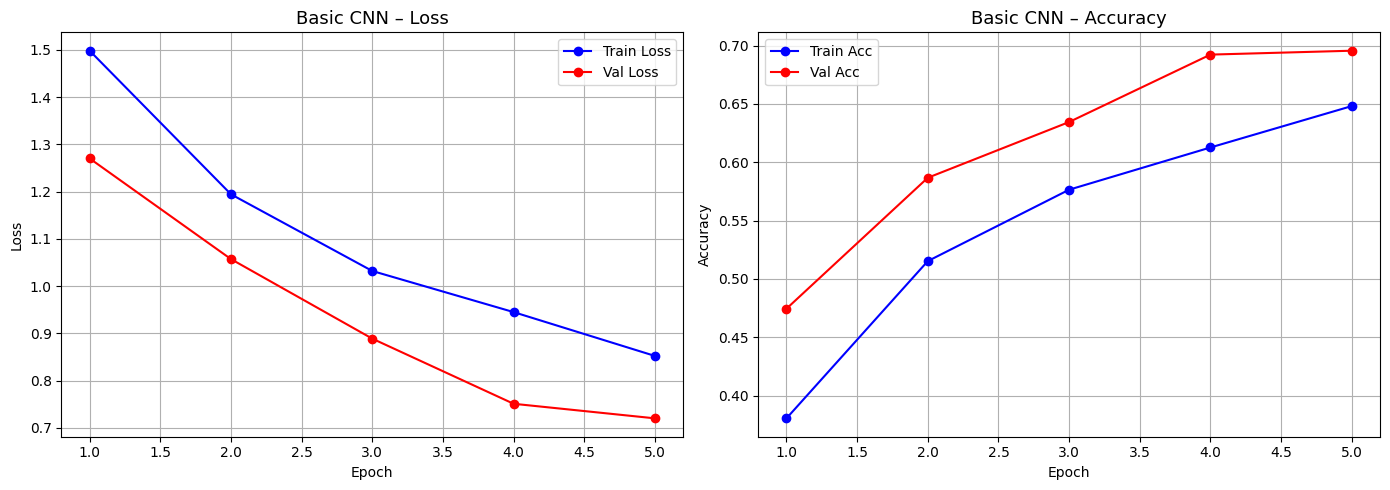

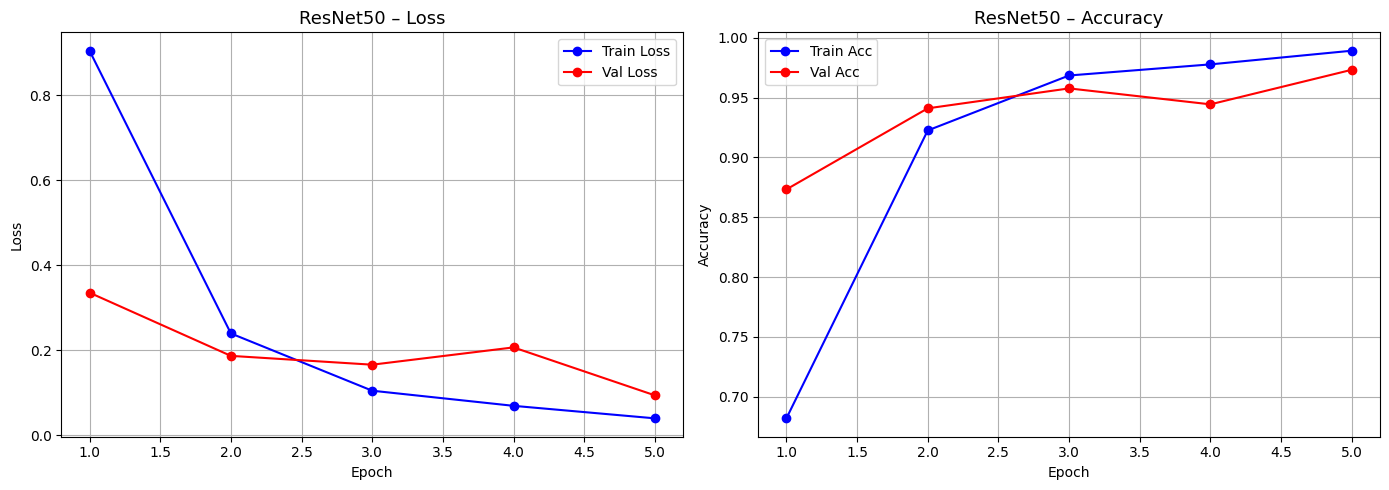

In [14]:
def plot_curves(history, title, filename):
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
    ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss')
    ax1.set_title(f'{title} – Loss', fontsize=13)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True)

    ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc')
    ax2.plot(epochs_range, history['val_acc'],   'r-o', label='Val Acc')
    ax2.set_title(f'{title} – Accuracy', fontsize=13)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.savefig(filename, dpi=100)
    plt.show()

plot_curves(cnn_history, 'Basic CNN',     'cnn_curves.png')
plot_curves(rn_history,  'ResNet50',      'resnet_curves.png')

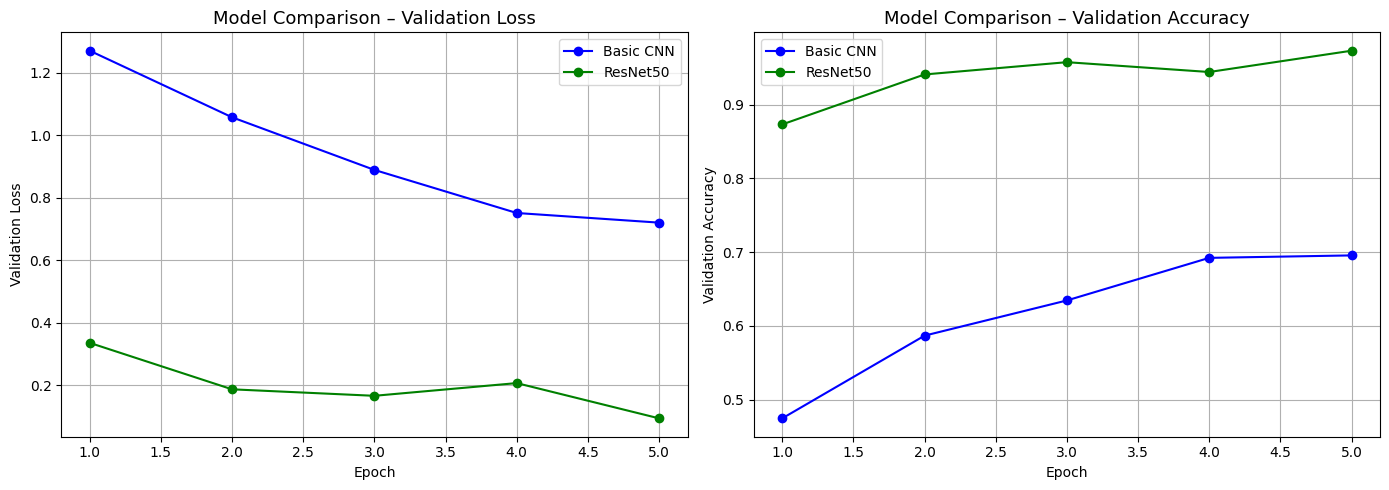

In [15]:
# Side-by-side comparison
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel in zip(axes, ['val_loss', 'val_acc'], ['Validation Loss', 'Validation Accuracy']):
    ax.plot(epochs_range, cnn_history[metric], 'b-o', label='Basic CNN')
    ax.plot(epochs_range, rn_history[metric],  'g-o', label='ResNet50')
    ax.set_title(f'Model Comparison – {ylabel}', fontsize=13)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=100)
plt.show()

### Discussion: Why Pretrained Models Often Outperform Scratch Models

ResNet50 was pretrained on ImageNet (1.2 million images, 1000 classes), so its convolutional layers already encode powerful, generalizable visual features — edges, textures, gradients, and higher-level patterns. Fine-tuning only the final layers forces the model to adapt these rich representations to the AQI classification task rather than learning everything from random weights.

A basic CNN trained from scratch must learn all feature hierarchies solely from our small dataset, which typically leads to:
- **Higher variance / overfitting** — the model memorizes training data
- **Slower convergence** — many more epochs needed
- **Weaker generalization** — especially on underrepresented AQI classes

In this dataset, transfer learning is expected to help significantly because AQI images share visual characteristics (haze, colour cast, texture) that ResNet's ImageNet features already encode.

## Task 4 – Confusion Matrices

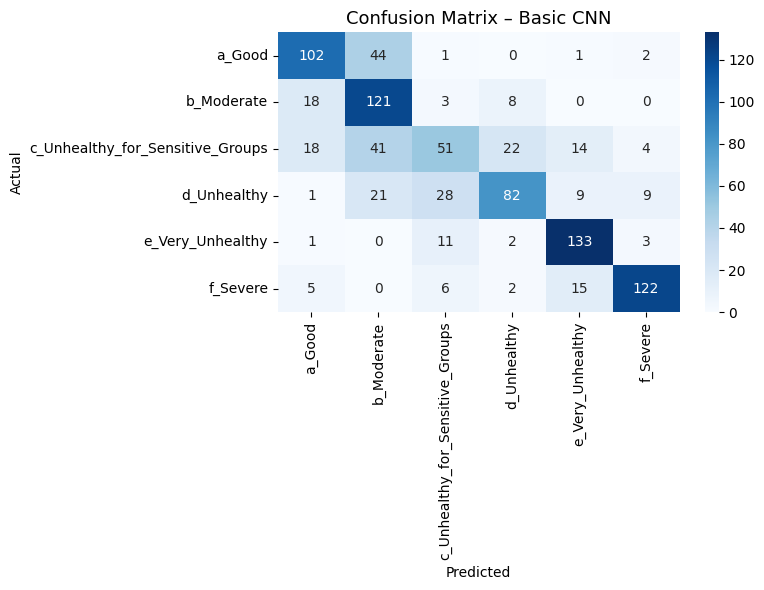

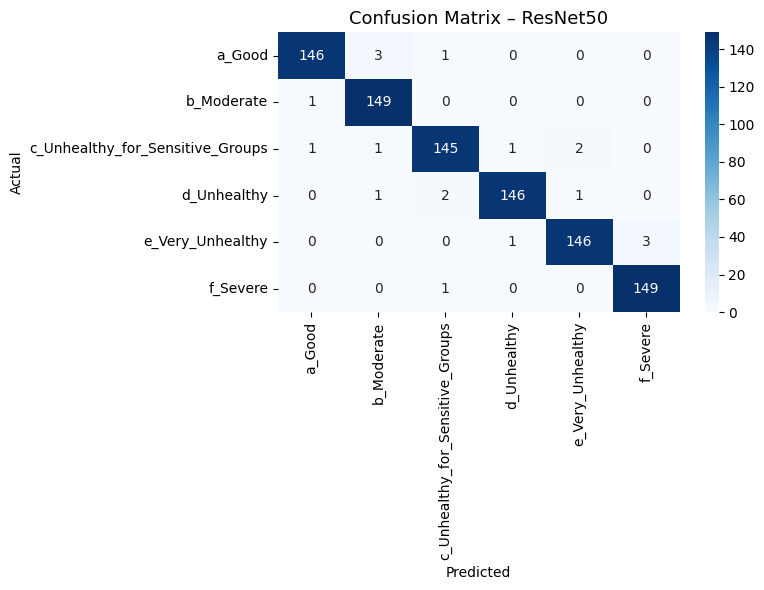

In [16]:
def plot_confusion_matrix(y_true, y_pred, class_names, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=13)
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(filename, dpi=100)
    plt.show()

plot_confusion_matrix(cnn_true, cnn_preds, classes, 'Confusion Matrix – Basic CNN',    'cm_cnn.png')
plot_confusion_matrix(rn_true,  rn_preds,  classes, 'Confusion Matrix – ResNet50',     'cm_resnet.png')

In [17]:
# ─── Metrics Summary Table ─────────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

def metrics_summary(y_true, y_pred, model_name):
    return {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }

results = pd.DataFrame([
    metrics_summary(cnn_true, cnn_preds, 'Basic CNN'),
    metrics_summary(rn_true,  rn_preds,  'ResNet50 (Transfer Learning)'),
])
print('\n=== Performance Summary ===')
print(results.to_string(index=False))


=== Performance Summary ===
                       Model  Accuracy  Precision  Recall  F1-Score
                   Basic CNN    0.6789      0.683  0.6789    0.6709
ResNet50 (Transfer Learning)    0.9789      0.979  0.9789    0.9789


## Task 6 – Misclassification Analysis

In [18]:
def get_misclassified_samples(model, dataframe, images_dir, transform, n=10):
    """Return (image_tensors, true_labels, pred_labels) for misclassified samples."""
    model.eval()
    misclassified = []
    df_reset = dataframe.reset_index(drop=True)

    with torch.no_grad():
        for idx in range(len(df_reset)):
            row      = df_reset.iloc[idx]
            img_path = os.path.join(images_dir, row['Filename'])
            image    = Image.open(img_path).convert('RGB')
            tensor   = transform(image).unsqueeze(0).to(DEVICE)
            pred     = model(tensor).argmax(1).item()
            true     = int(row['label'])
            if pred != true:
                misclassified.append((image, true, pred))
            if len(misclassified) >= n:
                break
    return misclassified

misc_samples = get_misclassified_samples(resnet, test_df, IMAGES_DIR, eval_transforms, n=10)
print(f'Found {len(misc_samples)} misclassified samples to visualise.')

Found 10 misclassified samples to visualise.


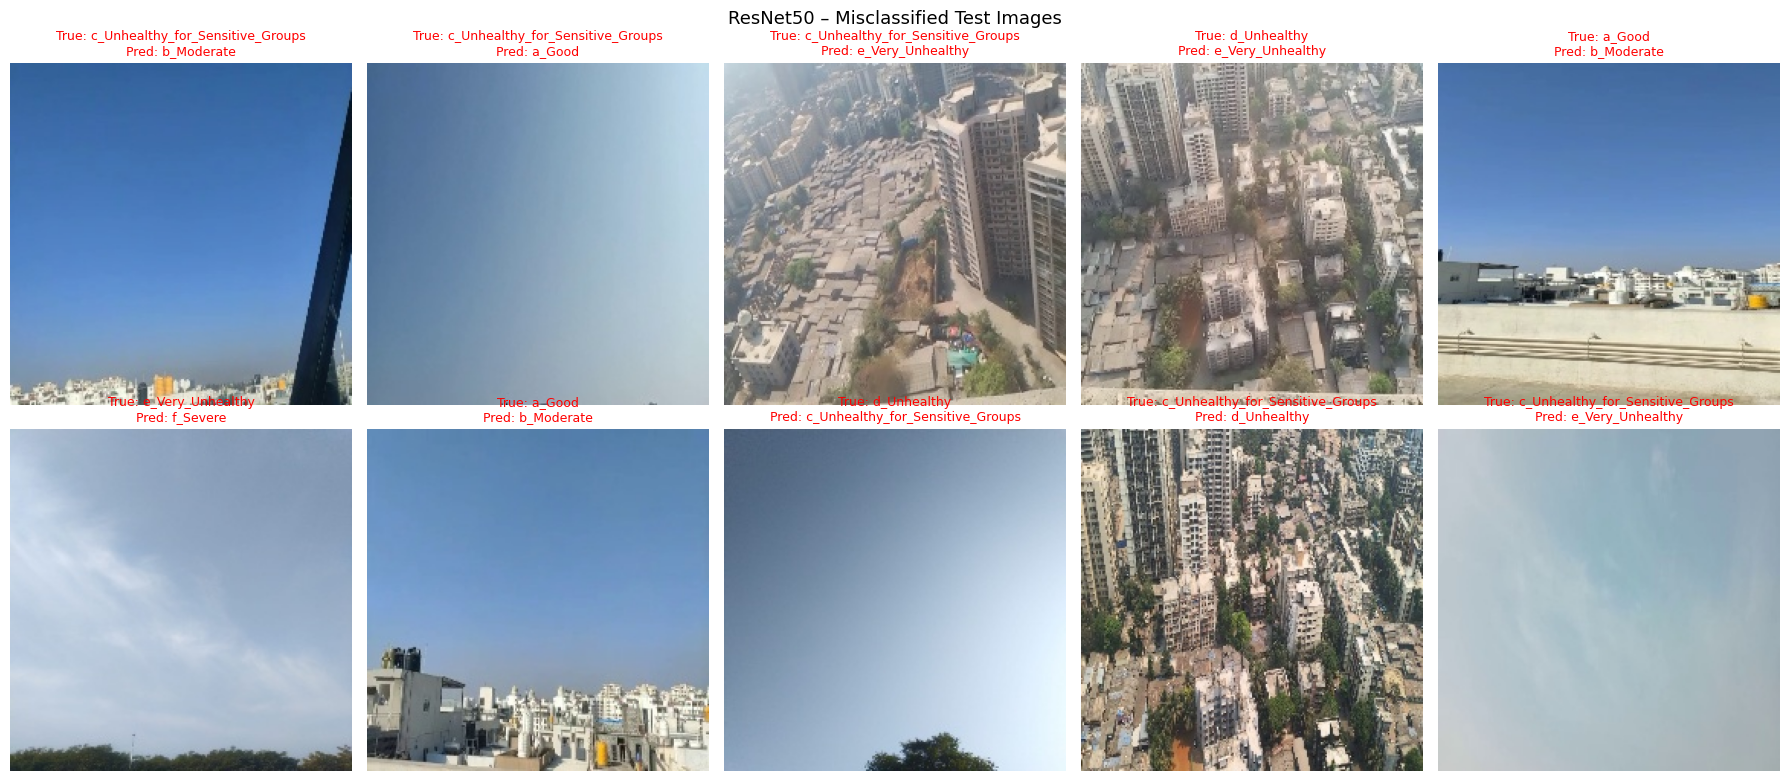

In [19]:
n_show = min(10, len(misc_samples))
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis('off')
        continue
    img, true_lbl, pred_lbl = misc_samples[i]
    ax.imshow(img.resize((224, 224)))
    ax.set_title(f'True: {idx_to_class[true_lbl]}\nPred: {idx_to_class[pred_lbl]}',
                 fontsize=9, color='red')
    ax.axis('off')

plt.suptitle('ResNet50 – Misclassified Test Images', fontsize=13)
plt.tight_layout()
plt.savefig('misclassified_images.png', dpi=100)
plt.show()

### Possible Reasons for Misclassification

1. **Visual ambiguity between adjacent AQI classes** – e.g., *Moderate* and *Unhealthy for Sensitive Groups* images can look nearly identical; haze levels differ subtly.
2. **Lighting and time-of-day variation** – the same location can appear more/less hazy depending on sunlight angle, making the model rely on colour cues that are inconsistent.
3. **Occlusions and non-air objects** – buildings, trees, or water bodies in the foreground may mislead the model into incorrect predictions.
4. **Class imbalance** – underrepresented classes (e.g., *Hazardous*) provide fewer gradient signals, so the model under-learns those boundaries.
5. **Limited training epochs** – with only 5 epochs, the decision boundaries have not fully converged, particularly for fine-grained visual differences.

## Results Summary

In [20]:
print('=' * 55)
print('         FINAL RESULTS SUMMARY')
print('=' * 55)
print(results.to_string(index=False))
print('=' * 55)
print(f'\nWinner: {results.loc[results["F1-Score"].idxmax(), "Model"]}')
print('\nConclusion:')
print('  ResNet50 with transfer learning leverages features')
print('  pretrained on 1.2M images, giving it a significant')
print('  head-start over a CNN trained from scratch in just')
print('  5 epochs on a limited AQI image dataset.')

         FINAL RESULTS SUMMARY
                       Model  Accuracy  Precision  Recall  F1-Score
                   Basic CNN    0.6789      0.683  0.6789    0.6709
ResNet50 (Transfer Learning)    0.9789      0.979  0.9789    0.9789

Winner: ResNet50 (Transfer Learning)

Conclusion:
  ResNet50 with transfer learning leverages features
  pretrained on 1.2M images, giving it a significant
  head-start over a CNN trained from scratch in just
  5 epochs on a limited AQI image dataset.
